# IEQ All-Model Hyperparameter Tuning

This notebook performs the full all-model tuning step for the IEQ satisfaction paper. It searches hyperparameters for each candidate model family with macro F1 as the primary objective, saves the complete tuning trace, and then re-evaluates the selected settings with a matched 5-fold protocol.

Macro F1 is treated as the main metric because the target classes are imbalanced. Accuracy, balanced accuracy, and ordinal MAE are reported as supporting metrics so that the final model choice is transparent rather than based on a single number.

## 1. Imports and Configuration

This section defines shared paths, plotting style, model order, class labels, and the scoring setup used throughout the notebook. The tuning search refits by macro F1 while also recording accuracy and balanced accuracy for interpretation.

In [1]:
from __future__ import annotations

import contextlib
import json
import joblib
import sys
import time
import warnings
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display  # type: ignore
except ModuleNotFoundError:
    def display(value):
        print(value)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATASET_RELATIVE_PATH = Path("02_Datasets") / "model_ready" / "ieq_model_dataset.xlsx"
DATASET_FILE_NAME = "ieq_model_dataset.xlsx"


def find_dataset_path() -> Path:
    search_roots = [Path.cwd(), *Path.cwd().parents]
    candidates = []
    for root in search_roots:
        candidates.extend(
            [
                root / DATASET_RELATIVE_PATH,
                root / "Prism" / DATASET_RELATIVE_PATH,
                root / DATASET_FILE_NAME,
            ]
        )
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find ieq_model_dataset.xlsx. Keep the Prism folder structure, "
        "or place ieq_model_dataset.xlsx in the current notebook folder."
    )


DATASET_PATH = find_dataset_path()
if DATASET_PATH.parent.name == "model_ready" and DATASET_PATH.parent.parent.name == "02_Datasets":
    PROJECT_ROOT = DATASET_PATH.parent.parent.parent
    OUTPUT_DIR = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs"
else:
    PROJECT_ROOT = Path.cwd()
    OUTPUT_DIR = PROJECT_ROOT / "ieq_model_outputs"

STYLE_DIR = Path.cwd()
for root in [Path.cwd(), *Path.cwd().parents]:
    candidate = root / "03_Code" / "ieq_paper" / "01_notebook"
    if (candidate / "paper_style.py").exists():
        STYLE_DIR = candidate.resolve()
        break
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))

from paper_style import COLORS as PAPER_COLORS, apply_paper_style, plot_confusion_matrix, save_figure, style_axes

apply_paper_style()
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

SEED = 20260507
TUNING_SPLITS = 5
EVALUATION_SPLITS = 5
PRIMARY_SCORING = "macro_f1"
SEARCH_SCORING = {
    "macro_f1": "f1_macro",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
}
SEARCH_N_JOBS = 1
CLASS_ORDER = ["dissatisfied", "neutral", "satisfied"]
CLASS_TO_NUMBER = {label: index for index, label in enumerate(CLASS_ORDER)}
NUMBER_TO_CLASS = {index: label for label, index in CLASS_TO_NUMBER.items()}
CLASS_DISPLAY_LABELS = ["Dissatisfied", "Neutral", "Satisfied"]

MODEL_ORDER = ["Logistic regression", "Random Forest", "Extra Trees", "Gradient boosting", "ANN / MLP"]
MODEL_LABELS = {
    "Logistic regression": "Logistic\nregression",
    "Random Forest": "Random\nForest",
    "Extra Trees": "Extra\nTrees",
    "Gradient boosting": "Gradient\nboosting",
    "ANN / MLP": "ANN /\nMLP",
}
MODEL_COLORS = {
    "Logistic regression": PAPER_COLORS["dark_blue"],
    "Random Forest": PAPER_COLORS["secondary_green"],
    "Extra Trees": PAPER_COLORS["best"],
    "Gradient boosting": PAPER_COLORS["medium"],
    "ANN / MLP": PAPER_COLORS["purple"],
}
def model_value_label_color(model: str) -> str:
    return PAPER_COLORS["text"] if model == "Gradient boosting" else "white"

TARGET = "IEQ satisfaction 3-class"
DROP_FROM_FEATURES = ["IEQ satisfaction 3-class", "TimeVote"]
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load Dataset

The model-ready IEQ dataset is loaded from the project structure. The table below confirms the number of observations, predictors, and the three-class target distribution before any model fitting starts.

In [2]:

data = pd.read_excel(DATASET_PATH, sheet_name="data")
feature_columns = [column for column in data.columns if column not in DROP_FROM_FEATURES]

X = data[feature_columns].copy()
y_labels = data[TARGET].astype(str)
unknown_labels = sorted(set(y_labels.dropna()) - set(CLASS_ORDER))
if unknown_labels:
    raise ValueError(f"Unexpected target labels in {TARGET}: {unknown_labels}")
y = y_labels.map(CLASS_TO_NUMBER).astype(int)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

dataset_overview = pd.DataFrame(
    [
        {"item": "dataset", "value": DATASET_PATH.name},
        {"item": "rows", "value": data.shape[0]},
        {"item": "columns", "value": data.shape[1]},
        {"item": "target", "value": TARGET},
        {"item": "predictors", "value": len(feature_columns)},
    ]
)
class_distribution = y_labels.value_counts().reindex(CLASS_ORDER).rename("rows").to_frame()
class_distribution["percent"] = (y_labels.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(1)

display(dataset_overview)
display(class_distribution)


,item,value
0,dataset,ieq_model_dataset.xlsx
1,rows,6834
2,columns,22
3,target,IEQ satisfaction 3-class
4,predictors,20


,rows,percent
IEQ satisfaction 3-class,,
dissatisfied,484,7.1
neutral,1855,27.1
satisfied,4495,65.8


## 3. Preprocessing, Metrics, and Search Spaces

Every model is wrapped in the same preprocessing pipeline: numeric predictors are standardized and categorical predictors are one-hot encoded inside each cross-validation fold. This prevents information from the validation fold from leaking into preprocessing.

The search spaces below are deliberately finite and fully enumerated. Instead of sampling a large grid at random, this notebook uses `GridSearchCV` and tests every listed hyperparameter combination. The grids are therefore kept to plausible values only: broad enough to learn something, but small enough that the whole predefined grid can be audited and reproduced exactly.

In [3]:
def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ],
        remainder="drop",
    )


def make_pipeline(base_model) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", base_model),
        ]
    )


def as_number_array(values: pd.Series | np.ndarray) -> np.ndarray:
    series = pd.Series(values)
    if pd.api.types.is_numeric_dtype(series):
        return series.to_numpy(dtype=int)
    return series.map(CLASS_TO_NUMBER).to_numpy(dtype=int)


def as_label_array(values: pd.Series | np.ndarray) -> np.ndarray:
    return pd.Series(as_number_array(values)).map(NUMBER_TO_CLASS).to_numpy()


def ordinal_mae(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    true_numbers = as_number_array(y_true)
    pred_numbers = as_number_array(y_pred)
    return mean_absolute_error(true_numbers, pred_numbers)


def evaluate_predictions(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true_numbers = as_number_array(y_true)
    y_pred_numbers = as_number_array(y_pred)
    return {
        "macro_f1": float(f1_score(y_true_numbers, y_pred_numbers, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true_numbers, y_pred_numbers)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true_numbers, y_pred_numbers)),
        "weighted_f1": float(f1_score(y_true_numbers, y_pred_numbers, average="weighted", zero_division=0)),
        "ordinal_mae": float(ordinal_mae(y_true_numbers, y_pred_numbers)),
    }


def make_model_specs() -> dict[str, dict]:
    return {
        "Logistic regression": {
            "estimator": LogisticRegression(max_iter=3000, random_state=SEED),
            "params": {
                "model__C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
                "model__class_weight": ["balanced", None],
                "model__solver": ["lbfgs"],
            },
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(n_jobs=1, random_state=SEED),
            "params": {
                "model__n_estimators": [300, 600],
                "model__criterion": ["gini", "entropy"],
                "model__max_depth": [None, 16, 24],
                "model__min_samples_leaf": [2, 4, 8],
                "model__min_samples_split": [2, 10],
                "model__max_features": ["sqrt", 0.5],
                "model__class_weight": ["balanced", "balanced_subsample"],
            },
        },
        "Extra Trees": {
            "estimator": ExtraTreesClassifier(n_jobs=1, random_state=SEED),
            "params": [
                {
                    "model__n_estimators": [500, 700],
                    "model__criterion": ["entropy"],
                    "model__max_depth": [None, 20],
                    "model__min_samples_leaf": [1, 2, 4],
                    "model__min_samples_split": [2, 10],
                    "model__max_features": ["sqrt", None],
                    "model__class_weight": ["balanced", "balanced_subsample"],
                    "model__bootstrap": [False],
                },
                {
                    "model__n_estimators": [500, 700],
                    "model__criterion": ["entropy"],
                    "model__max_depth": [None, 20],
                    "model__min_samples_leaf": [1, 2, 4],
                    "model__min_samples_split": [2, 10],
                    "model__max_features": ["sqrt", None],
                    "model__class_weight": ["balanced", "balanced_subsample"],
                    "model__bootstrap": [True],
                    "model__max_samples": [0.8, 0.9],
                },
            ],
        },
        "Gradient boosting": {
            "estimator": GradientBoostingClassifier(random_state=SEED),
            "params": {
                "model__n_estimators": [100, 160, 220],
                "model__learning_rate": [0.04, 0.06, 0.08],
                "model__max_depth": [2, 3],
                "model__min_samples_leaf": [3, 10],
                "model__subsample": [0.85, 1.0],
                "model__max_features": [None, "sqrt"],
            },
        },
        "ANN / MLP": {
            "estimator": MLPClassifier(max_iter=400, early_stopping=True, random_state=SEED),
            "params": {
                "model__hidden_layer_sizes": [(32,), (64,), (32, 16), (64, 32)],
                "model__activation": ["relu", "tanh"],
                "model__alpha": [0.001, 0.003, 0.01],
                "model__learning_rate_init": [0.001, 0.003],
                "model__batch_size": [64, 128],
            },
        },
    }


def count_search_candidates(param_grid) -> int:
    return len(ParameterGrid(param_grid))


def saved_files_table(paths) -> pd.DataFrame:
    rows = []
    for output_path in paths:
        path = Path(output_path)
        try:
            saved_file = path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
        except ValueError:
            saved_file = path.as_posix()
        rows.append(
            {
                "saved_file": saved_file,
                "file_name": path.name,
                "folder": path.parent.name,
            }
        )
    return pd.DataFrame(rows)

## 4. Tune Hyperparameters

This section runs `GridSearchCV` separately for each model family. The primary selection metric is macro F1, but the same cross-validation run also records accuracy and balanced accuracy. Every candidate in the predefined grid is evaluated across the same five stratified folds.

The saved `hyperparameter_tuning_cv_results.csv` file contains every tried configuration, its rank, metric values, and fit time. The compact table shown here reports the best configuration per model. Because this is a full grid search with fixed folds and fixed model seeds, repeated runs of the notebook should select the same configurations and produce the same results, apart from tiny platform-level numeric differences.

In [4]:
class ParallelTracker:
    depth = 0
    main_parallel_completed = False


@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    ParallelTracker.depth = 0
    ParallelTracker.main_parallel_completed = False

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            if not ParallelTracker.main_parallel_completed:
                tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    old_parallel_call = joblib.Parallel.__call__
    
    def new_parallel_call(self, iterable, *args, **kwargs):
        is_top_level = False
        if ParallelTracker.depth == 0 and not ParallelTracker.main_parallel_completed:
            is_top_level = True
        
        ParallelTracker.depth += 1
        try:
            if is_top_level:
                if self._effective_n_jobs() == 1:
                    def tqdm_iterable(it):
                        for item in it:
                            yield item
                            tqdm_object.update(1)
                    iterable = tqdm_iterable(iterable)
            return old_parallel_call(self, iterable, *args, **kwargs)
        finally:
            ParallelTracker.depth -= 1
            if is_top_level:
                ParallelTracker.main_parallel_completed = True

    joblib.Parallel.__call__ = new_parallel_call
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        joblib.Parallel.__call__ = old_parallel_call


model_specs = make_model_specs()
search_cv = StratifiedKFold(n_splits=TUNING_SPLITS, shuffle=True, random_state=SEED)

best_params = {}
best_rows = []
cv_result_frames = []

for model_name in MODEL_ORDER:
    spec = model_specs[model_name]
    pipeline = make_pipeline(clone(spec["estimator"]))
    total_candidates = count_search_candidates(spec["params"])
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["params"],
        scoring=SEARCH_SCORING,
        refit=PRIMARY_SCORING,
        cv=search_cv,
        n_jobs=SEARCH_N_JOBS,
        verbose=0,
        error_score="raise",
        return_train_score=False,
    )

    print(
        f"\nTuning {model_name}: testing all {total_candidates} predefined candidate configurations "
        f"across {TUNING_SPLITS} folds ({total_candidates * TUNING_SPLITS} fits)."
    )
    start = time.perf_counter()
    total_fits = total_candidates * TUNING_SPLITS
    with tqdm(total=total_fits, desc=f"Tuning {model_name}") as pbar:
        with tqdm_joblib(pbar):
            search.fit(X, y)
    elapsed = time.perf_counter() - start

    best_index = int(search.best_index_)
    best_params[model_name] = search.best_params_
    best_rows.append(
        {
            "model": model_name,
            "n_candidates_tested": total_candidates,
            "total_grid_candidates": total_candidates,
            "tuning_fits": total_candidates * TUNING_SPLITS,
            "best_cv_macro_f1": search.best_score_,
            "best_cv_accuracy": search.cv_results_["mean_test_accuracy"][best_index],
            "best_cv_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][best_index],
            "tuning_seconds": elapsed,
            "best_params_json": json.dumps(search.best_params_, sort_keys=True),
        }
    )

    cv_results = pd.DataFrame(search.cv_results_)
    result_columns = [
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "std_test_macro_f1",
        "mean_test_accuracy",
        "std_test_accuracy",
        "mean_test_balanced_accuracy",
        "std_test_balanced_accuracy",
        "mean_fit_time",
        "std_fit_time",
        "params",
    ]
    cv_results = cv_results[result_columns].copy()
    cv_results.insert(0, "model", model_name)
    cv_results.insert(1, "n_candidates_tested", total_candidates)
    cv_results.insert(2, "total_grid_candidates", total_candidates)
    cv_results["params_json"] = cv_results["params"].apply(lambda value: json.dumps(value, sort_keys=True))
    cv_results = cv_results.drop(columns="params")
    cv_result_frames.append(cv_results)

best_params_table = pd.DataFrame(best_rows).sort_values("best_cv_macro_f1", ascending=False)
tuning_results = pd.concat(cv_result_frames, ignore_index=True)

best_params_path = TABLE_DIR / "hyperparameter_tuning_best_params.csv"
tuning_results_path = TABLE_DIR / "hyperparameter_tuning_cv_results.csv"
best_params_table.to_csv(best_params_path, index=False)
tuning_results.to_csv(tuning_results_path, index=False)

best_params_display = best_params_table[
    [
        "model",
        "n_candidates_tested",
        "tuning_fits",
        "best_cv_macro_f1",
        "best_cv_accuracy",
        "best_cv_balanced_accuracy",
        "tuning_seconds",
    ]
].copy()
for column in ["best_cv_macro_f1", "best_cv_accuracy", "best_cv_balanced_accuracy", "tuning_seconds"]:
    best_params_display[column] = best_params_display[column].round(4)

print("Best hyperparameters by model, ranked by macro F1")
display(best_params_display)
print("Saved tuning outputs")
display(saved_files_table([best_params_path, tuning_results_path]))



Tuning Logistic regression: testing all 14 predefined candidate configurations across 5 folds (70 fits).


Tuning Logistic regression:   0%|          | 0/70 [00:00<?, ?it/s]


Tuning Random Forest: testing all 288 predefined candidate configurations across 5 folds (1440 fits).


Tuning Random Forest:   0%|          | 0/1440 [00:00<?, ?it/s]


Tuning Extra Trees: testing all 288 predefined candidate configurations across 5 folds (1440 fits).


...

Tuning ANN / MLP:   0%|          | 0/480 [00:00<?, ?it/s]

Best hyperparameters by model, ranked by macro F1


,model,n_candidates_tested,tuning_fits,best_cv_macro_f1,best_cv_accuracy,best_cv_balanced_accuracy,tuning_seconds
2,Extra Trees,288,1440,0.5949,0.7234,0.5957,5847.1628
1,Random Forest,288,1440,0.5897,0.7167,0.5923,5381.3197
4,ANN / MLP,96,480,0.5160,0.7062,0.4918,629.5850
3,Gradient boosting,144,720,0.4976,0.6964,0.4734,1304.0309
0,Logistic regression,14,70,0.4025,0.4835,0.4677,12.2643


Saved tuning outputs


,saved_file,file_name,folder
0,03_Code/ieq_paper/02_outputs/tables/hyperparameter_tuning_best_params.csv,hyperparameter_tuning_best_params.csv,tables
1,03_Code/ieq_paper/02_outputs/tables/hyperparameter_tuning_cv_results.csv,hyperparameter_tuning_cv_results.csv,tables


## 5. Evaluate Tuned Models

The best hyperparameters from Section 4 are evaluated again with a matched five-fold out-of-fold protocol. This produces fold-level metrics, out-of-fold predictions, and a summary table that can be reused by the paper figures.

The saved-file table uses project-relative paths so the file names remain visible in the notebook display.

In [5]:
evaluation_cv = StratifiedKFold(n_splits=EVALUATION_SPLITS, shuffle=True, random_state=SEED)
fold_rows = []
prediction_rows = []

for model_name in MODEL_ORDER:
    print(f"\nEvaluating tuned {model_name}...")
    spec = model_specs[model_name]
    for fold, (train_index, test_index) in enumerate(evaluation_cv.split(X, y), start=1):
        pipeline = make_pipeline(clone(spec["estimator"]))
        pipeline.set_params(**best_params[model_name])
        if "model__random_state" in pipeline.get_params():
            pipeline.set_params(model__random_state=SEED + fold)

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        y_pred = pipeline.predict(X_test)
        predict_seconds = time.perf_counter() - start

        row = {
            "model": model_name,
            "fold": fold,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
            "total_seconds": fit_seconds + predict_seconds,
        }
        row.update(evaluate_predictions(y_test, y_pred))
        fold_rows.append(row)

        for row_index, true_label, predicted_label in zip(test_index, y_test, y_pred):
            prediction_rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "row_index": row_index,
                    "true_label": NUMBER_TO_CLASS[int(true_label)],
                    "predicted_label": NUMBER_TO_CLASS[int(predicted_label)],
                }
            )

fold_results = pd.DataFrame(fold_rows)
cv_predictions = pd.DataFrame(prediction_rows)
metric_columns = ["macro_f1", "accuracy", "balanced_accuracy", "weighted_f1", "ordinal_mae", "fit_seconds", "predict_seconds", "total_seconds"]

summary = fold_results.groupby("model")[metric_columns].agg(["mean", "std"])
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.reset_index()
summary["macro_f1_per_second"] = summary["macro_f1_mean"] / summary["total_seconds_mean"]
summary = summary.merge(best_params_table, on="model", how="left")

folds_paths = (TABLE_DIR / "tuned_model_comparison_5fold_folds.csv", TABLE_DIR / "model_comparison_5fold_folds.csv")
predictions_paths = (TABLE_DIR / "tuned_model_comparison_5fold_predictions.csv", TABLE_DIR / "model_comparison_5fold_predictions.csv")
summary_paths = (TABLE_DIR / "tuned_model_comparison_5fold_summary.csv", TABLE_DIR / "model_comparison_5fold_summary.csv")
for folds_path in folds_paths:
    fold_results.to_csv(folds_path, index=False)
for predictions_path in predictions_paths:
    cv_predictions.to_csv(predictions_path, index=False)
for summary_path in summary_paths:
    summary.to_csv(summary_path, index=False)

evaluation_display = summary.sort_values("macro_f1_mean", ascending=False)[
    [
        "model",
        "macro_f1_mean",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "ordinal_mae_mean",
        "best_cv_macro_f1",
        "best_cv_accuracy",
    ]
].copy()
for column in evaluation_display.select_dtypes(include=["float"]).columns:
    evaluation_display[column] = evaluation_display[column].round(4)

saved_evaluation_files = saved_files_table([*folds_paths, *predictions_paths, *summary_paths])

print("Out-of-fold performance of tuned models")
display(evaluation_display)
print("Saved evaluation outputs")
display(saved_evaluation_files)


Evaluating tuned Logistic regression...

Evaluating tuned Random Forest...

Evaluating tuned Extra Trees...

Evaluating tuned Gradient boosting...

Evaluating tuned ANN / MLP...
Out-of-fold performance of tuned models


,model,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean,best_cv_macro_f1,best_cv_accuracy
1,Extra Trees,0.5923,0.7233,0.5938,0.3137,0.5949,0.7234
4,Random Forest,0.5874,0.7136,0.5897,0.3257,0.5897,0.7167
2,Gradient boosting,0.4972,0.6949,0.4729,0.3468,0.4976,0.6964
0,ANN / MLP,0.4939,0.6908,0.4762,0.3524,0.5160,0.7062
3,Logistic regression,0.4025,0.4835,0.4677,0.6687,0.4025,0.4835


Saved evaluation outputs


,saved_file,file_name,folder
0,03_Code/ieq_paper/02_outputs/tables/tuned_model_comparison_5fold_folds.csv,tuned_model_comparison_5fold_folds.csv,tables
1,03_Code/ieq_paper/02_outputs/tables/model_comparison_5fold_folds.csv,model_comparison_5fold_folds.csv,tables
2,03_Code/ieq_paper/02_outputs/tables/tuned_model_comparison_5fold_predictions.csv,tuned_model_comparison_5fold_predictions.csv,tables
3,03_Code/ieq_paper/02_outputs/tables/model_comparison_5fold_predictions.csv,model_comparison_5fold_predictions.csv,tables
4,03_Code/ieq_paper/02_outputs/tables/tuned_model_comparison_5fold_summary.csv,tuned_model_comparison_5fold_summary.csv,tables
5,03_Code/ieq_paper/02_outputs/tables/model_comparison_5fold_summary.csv,model_comparison_5fold_summary.csv,tables


## 6. Performance Figure

This section keeps only the main model-performance figure. Runtime and performance-efficiency trade-off plots are intentionally not generated here, because they are not part of the current paper-facing comparison.

Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\tuned_model_comparison_performance.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\tuned_model_comparison_performance.pdf
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\model_comparison_performance.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\model_comparison_performance.pdf


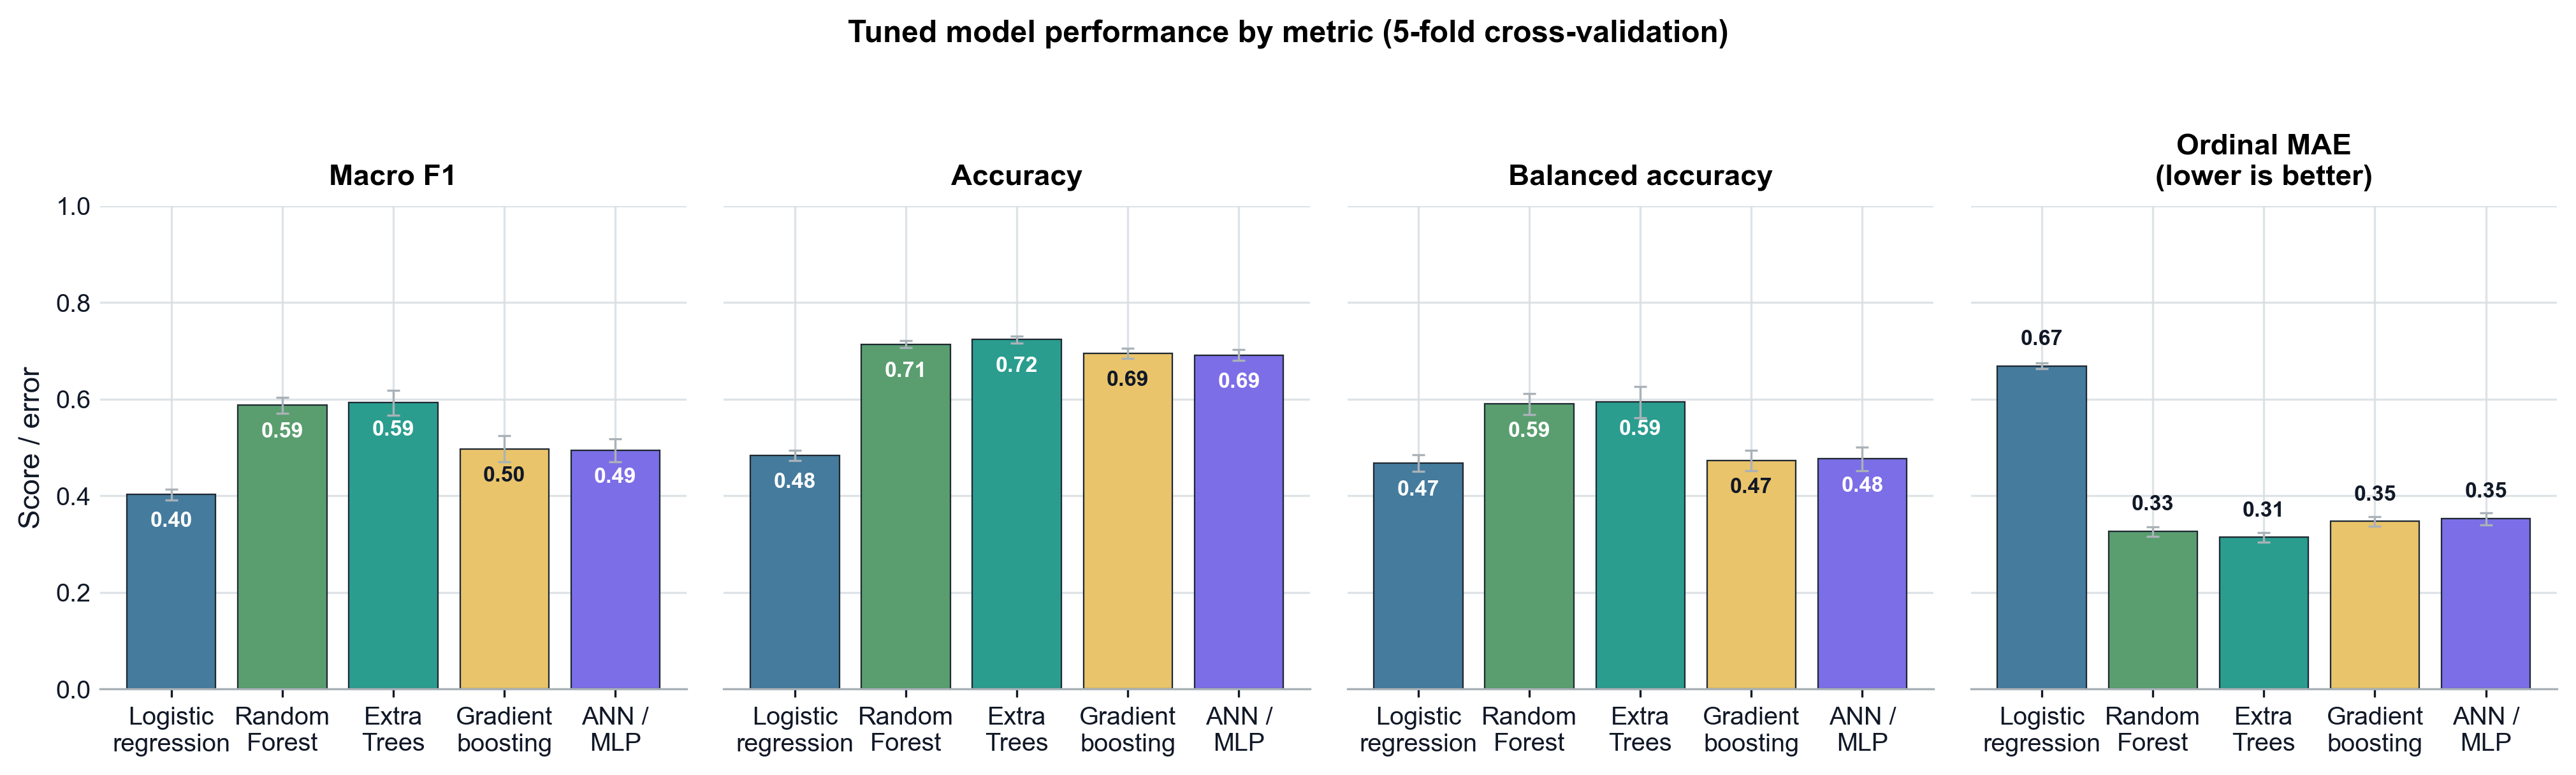

In [6]:
def save_current_figure(fig, name: str, *aliases: str) -> None:
    for figure_name in (name, *aliases):
        output_path = FIGURE_DIR / figure_name
        save_figure(fig, output_path)
        print("Saved", output_path.with_suffix(".png"))
        print("Saved", output_path.with_suffix(".pdf"))

plot_df = summary.set_index("model").reindex(MODEL_ORDER)
performance_metrics = [
    ("macro_f1_mean", "macro_f1_std", "Macro F1"),
    ("accuracy_mean", "accuracy_std", "Accuracy"),
    ("balanced_accuracy_mean", "balanced_accuracy_std", "Balanced accuracy"),
    ("ordinal_mae_mean", "ordinal_mae_std", "Ordinal MAE\n(lower is better)"),
]
x = np.arange(len(MODEL_ORDER))
bar_colors = [MODEL_COLORS[model] for model in MODEL_ORDER]

fig, axes = plt.subplots(ncols=4, figsize=(13.6, 3.9), sharey=True)
for ax, (mean_col, std_col, label) in zip(axes, performance_metrics):
    values = plot_df[mean_col].astype(float)
    errors = plot_df[std_col].astype(float)
    bars = ax.bar(
        x,
        values,
        yerr=errors,
        capsize=2.5,
        color=bar_colors,
        edgecolor=PAPER_COLORS["border"],
        linewidth=0.55,
        error_kw={"elinewidth": 0.8, "capthick": 0.8, "ecolor": PAPER_COLORS["axis"]},
    )
    for bar, model, value in zip(bars, MODEL_ORDER, values):
        label_y = value - 0.035 if mean_col != "ordinal_mae_mean" else value + 0.035
        label_va = "top" if mean_col != "ordinal_mae_mean" else "bottom"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{value:.2f}",
            ha="center",
            va=label_va,
            fontsize=8.2,
            fontweight="bold",
            color=model_value_label_color(model) if mean_col != "ordinal_mae_mean" else PAPER_COLORS["text"],
        )
    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[model] for model in MODEL_ORDER])
    style_axes(ax, grid_axis="y")

axes[0].set_ylabel("Score / error")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)

fig.suptitle("Tuned model performance by metric (5-fold cross-validation)", fontsize=11.5, fontweight="bold", y=1.03)
fig.tight_layout()
save_current_figure(fig, "tuned_model_comparison_performance", "model_comparison_performance")
plt.show()

## 7. Confusion Matrices

The confusion matrices use the out-of-fold predictions from Section 5. Rows are normalized to 100 percent, so each row shows where observations from one true class were assigned by the model. The darker blue scale matches the article confusion-matrix style.

Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\tables\tuned_model_confusion_matrices.csv
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\tables\model_confusion_matrices.csv
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\tuned_model_comparison_confusion_matrices.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\tuned_model_comparison_confusion_matrices.pdf
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\model_comparison_confusion_matrices.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\figures\model_comparison_confusion_matrices.pdf


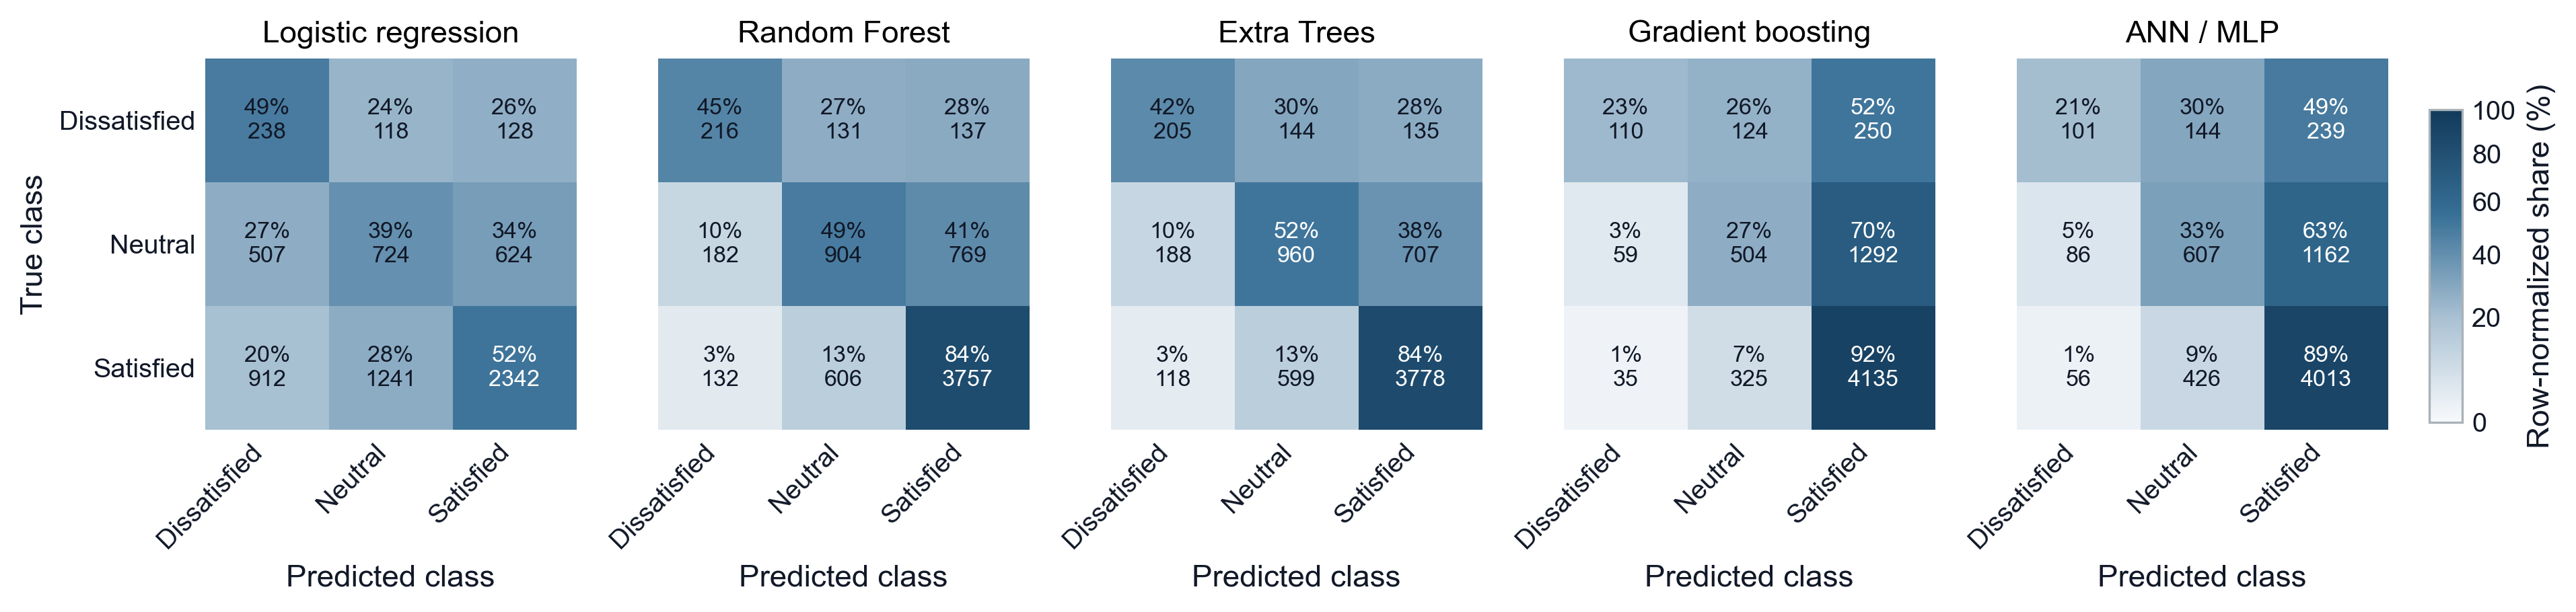

In [7]:
confusion_rows = []
fig, axes = plt.subplots(ncols=len(MODEL_ORDER), figsize=(13.6, 3.6), sharex=True, sharey=True)

image = None
for ax, model in zip(axes, MODEL_ORDER):
    model_predictions = cv_predictions[cv_predictions["model"] == model]
    counts = confusion_matrix(
        model_predictions["true_label"],
        model_predictions["predicted_label"],
        labels=CLASS_ORDER,
    )
    row_totals = counts.sum(axis=1, keepdims=True)
    normalized = counts / np.where(row_totals == 0, 1, row_totals) * 100

    for true_index, true_label in enumerate(CLASS_ORDER):
        for predicted_index, predicted_label in enumerate(CLASS_ORDER):
            confusion_rows.append(
                {
                    "model": model,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "count": int(counts[true_index, predicted_index]),
                    "row_percent": normalized[true_index, predicted_index],
                }
            )

    image, colorbar_label = plot_confusion_matrix(
        ax,
        counts,
        labels=CLASS_ORDER,
        display_labels=CLASS_DISPLAY_LABELS,
        title=MODEL_LABELS[model].replace("\n", " "),
        annotation_fontsize=8.2,
    )

for ax in axes[1:]:
    ax.set_ylabel("")

fig.subplots_adjust(wspace=0.22, bottom=0.27, top=0.82, right=0.92)
colorbar_axis = fig.add_axes([0.935, 0.30, 0.012, 0.43])
colorbar = fig.colorbar(image, cax=colorbar_axis)
colorbar.set_label(colorbar_label)

confusion_table = pd.DataFrame(confusion_rows)
for confusion_path in (TABLE_DIR / "tuned_model_confusion_matrices.csv", TABLE_DIR / "model_confusion_matrices.csv"):
    confusion_table.to_csv(confusion_path, index=False)
    print("Saved", confusion_path)

save_current_figure(fig, "tuned_model_comparison_confusion_matrices", "model_comparison_confusion_matrices")
plt.show()


## 8. Final Summary

The final table is sorted by macro F1, the primary metric. Columns are ordered from the most important selection metric to the supporting diagnostics: macro F1, accuracy, balanced accuracy, and ordinal MAE.

In [8]:
interpretation_columns = [
    "model",
    "macro_f1_mean",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "ordinal_mae_mean",
]

final_summary = summary[interpretation_columns].sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
for column in final_summary.select_dtypes(include=["float"]).columns:
    final_summary[column] = final_summary[column].round(4)

display(final_summary)

,model,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
0,Extra Trees,0.5923,0.7233,0.5938,0.3137
1,Random Forest,0.5874,0.7136,0.5897,0.3257
2,Gradient boosting,0.4972,0.6949,0.4729,0.3468
3,ANN / MLP,0.4939,0.6908,0.4762,0.3524
4,Logistic regression,0.4025,0.4835,0.4677,0.6687
